In [1]:
import numpy as np
from tifffile import imread, imwrite

In [2]:
import matplotlib.pyplot as plt
import stem_analysis.plot as saplt

In [34]:
from skimage.filters import window, sobel
from scipy.ndimage import gaussian_filter, maximum_filter
from skimage.transform import warp_polar
import stem_analysis.utils as sautils

In [4]:
import os

In [5]:
from itertools import combinations, permutations

In [6]:
%matplotlib widget

In [7]:
work_dir = '/Users/nihy/Desktop/Working Data/Lu166/ADF STEM/Fig 1 100 K'
data_dir = os.path.join(work_dir, 'Scan_ADF Image.raw')

In [8]:
#img = np.load(data_dir)
img = np.fromfile(data_dir, dtype=np.uint16).reshape((-1, 512, 512))
img.shape

(40, 512, 512)

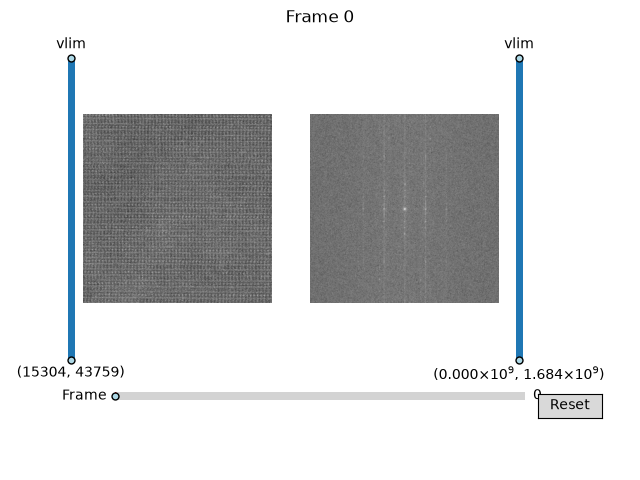

In [9]:
sviewer = saplt.SliceViewer(img)

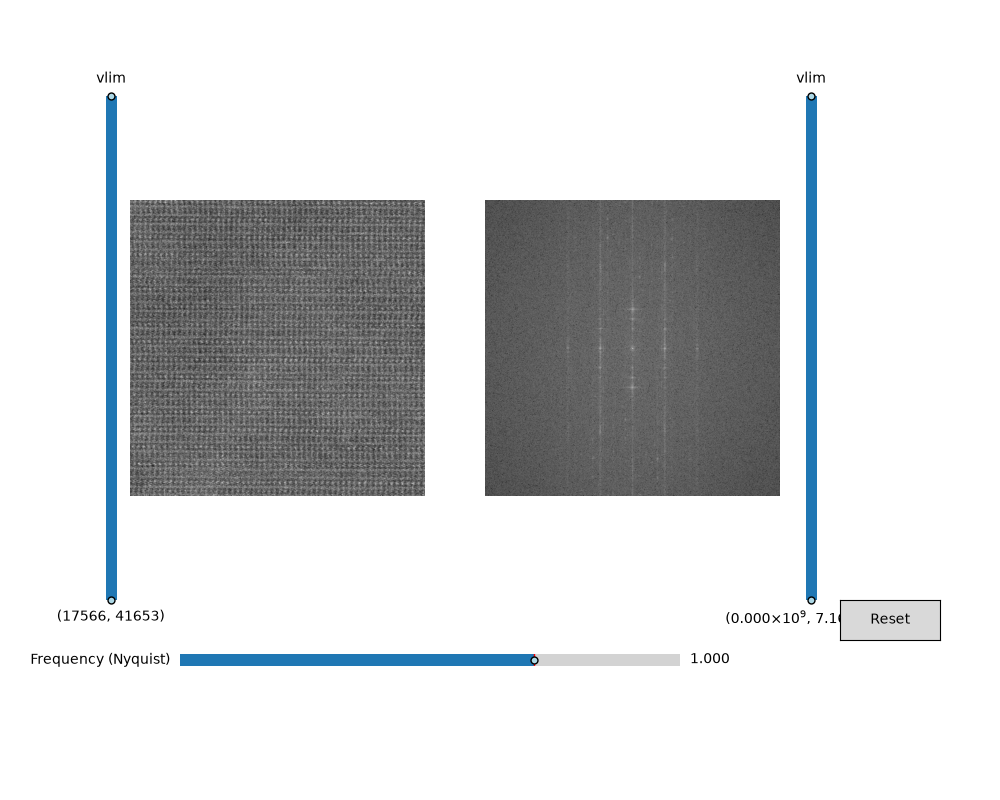

In [10]:
filter_viewer = saplt.SoftBandPassFilter(img[0])

In [11]:
sautils.SoftBandPassFilter(img[0], sigma_nyquist=0.05)

array([[27507.75313114, 27557.72117674, 27607.05361474, ...,
        27368.69383903, 27411.95248401, 27458.69300374],
       [27544.41842761, 27595.27118984, 27645.60812868, ...,
        27404.36833052, 27447.61175606, 27494.69955276],
       [27578.84374428, 27629.88928117, 27680.48262006, ...,
        27439.25195729, 27482.12485395, 27529.07032589],
       ...,
       [27393.60991178, 27436.10348487, 27477.41749131, ...,
        27269.52733795, 27309.35977928, 27351.02018866],
       [27431.22298541, 27477.03405459, 27521.86306497, ...,
        27299.9414945 , 27341.58948714, 27385.68430465],
       [27469.67941526, 27517.98257387, 27565.48950002, ...,
        27333.44936224, 27376.21604055, 27421.9899578 ]], shape=(512, 512))

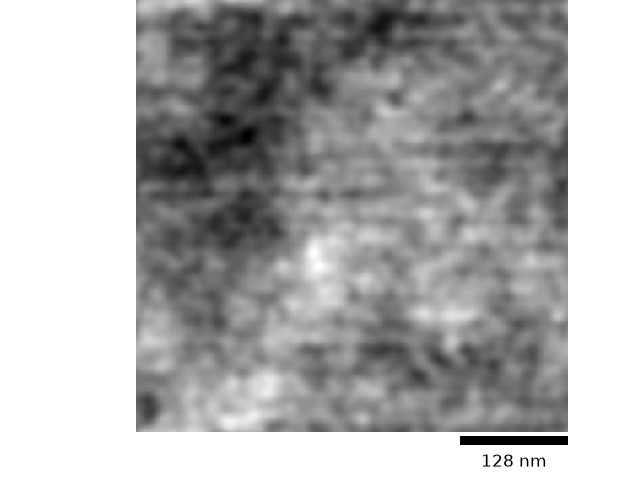

<Axes: >

In [13]:
fig = plt.figure()
saplt.PlotImage(fig, sautils.SoftBandPassFilter(img[0], sigma_nyquist=0.05), 1)

# perform cross-correlation

In [14]:
def cross_correlation(img1, img2):
    """
    Compute the cross-correlation of two 2D images.

    Parameters
    ----------
    img1 : np.ndarray
        First 2D image.
    img2 : np.ndarray
        Second 2D image.

    Returns
    -------
    np.ndarray
        Cross-correlation of the two images.
    """
    w1 = window('hann', img1.shape)
    w2 = window('hann', img2.shape)

    f1 = np.fft.fft2(img1)
    f2 = np.fft.fft2(img2)
    cross_corr = np.fft.ifft2(f1 * np.conj(f2))
    return np.fft.fftshift(np.abs(cross_corr))

In [15]:
def estimate_shift(img1, img2, max_shift = None, if_sobel = False):
    """
    Estimate the shift between two 2D images using cross-correlation.

    Parameters
    ----------
    img1 : np.ndarray
        First 2D image.
    img2 : np.ndarray
        Second 2D image.
    if sobel:
        from scipy.ndimage import sobel
        img1 = sobel(img1, axis=0) + sobel(img1, axis=1)
        img2 = sobel(img2, axis=0) + sobel(img2, axis=1)
    Returns
    -------
    tuple
        Estimated shift (dy, dx) between the two images.
    max_shift : int, optional
        Maximum allowed shift. If specified, the estimated shift will be clipped to this value.
    """
    if if_sobel:
            img1 = sobel(img1)
            img2 = sobel(img2)

    cross_corr = cross_correlation(img1, img2)
    max_idx = np.unravel_index(np.argmax(cross_corr), cross_corr.shape)
    midpoints = np.array([np.trunc(axis_size / 2) for axis_size in cross_corr.shape])
    
    if max_shift is not None:
        cc_mask = np.zeros_like(cross_corr, dtype=bool)
        y0, x0 = np.array(cross_corr.shape) // 2
        yy, xx = np.mgrid[:cross_corr.shape[0], :cross_corr.shape[1]]
        cc_mask[(np.abs(yy - y0) <= max_shift) & (np.abs(xx - x0) <= max_shift)] = True
        cross_corr = cross_corr * cc_mask
    

    shifts = np.array(max_idx) - midpoints
    
    return tuple(shifts)

In [16]:
def phase_cross_correlation(img1, img2):
    """
    Compute the cross-correlation of two 2D images.

    Parameters
    ----------
    img1 : np.ndarray
        First 2D image.
    img2 : np.ndarray
        Second 2D image.

    Returns
    -------
    np.ndarray
        Cross-correlation of the two images.
    """
    w1 = window('hann', img1.shape)
    w2 = window('hann', img2.shape)

    f1 = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img1)))
    f2 = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(img2)))
    C = f2 * np.conj(f1)

    phase = np.angle(C/np.abs(C))


    return phase

In [17]:
def estimate_shift_pcc(img1, img2, max_shift = None):
    phase = phase_cross_correlation(img1, img2)

    ny, nx = img1.shape

    kx = np.fft.fftshift(np.fft.fftfreq(nx))
    ky = np.fft.fftshift(np.fft.fftfreq(ny))

    KX, KY = np.meshgrid(kx, ky)
    if max_shift is not None:
        dx_max = max_shift[0]
        dy_max = max_shift[1]
        kx_max = 1 / (2 * dx_max)
        ky_max = 1 / (2 * dy_max)
        mask = np.sqrt((KX/kx_max)**2 + (KY/ky_max)**2) < 1

    else:
        k_cut = 0.1  # cycles / pixel
        mask = np.sqrt(KX**2 + KY**2) < k_cut

    A = np.column_stack([
        KX[mask],
        KY[mask],
        np.ones(np.sum(mask))
    ])

    b = phase[mask]

    coef, *_ = np.linalg.lstsq(A, b.ravel(), rcond=None)

    dx = coef[0] / (2*np.pi)
    dy = coef[1] / (2*np.pi)

    return dx, dy

In [81]:
def pairwise_shifts(stack, max_shift = None, if_sobel = False):
    """
    Returns shifts for every frame pair using the `estimate_shift` function.

    Parameters
    ----------
    stack : np.ndarray
        3D array of shape (Nframe, sx, sy) containing the image stack.
    max_shift : int, optional
        Maximum allowed shift for the `estimate_shift` function.
    if_sobel : bool, optional
        Whether to apply the Sobel filter before estimating shifts.
    
    Returns
    -------
    np.ndarray
        Array of shape (Nframe, Nframe, 2) containing the estimated shifts (dy, dx) for each frame pair.

    Each result row is:
      [reference_frame, moving_frame, dy, dx, error]

    (dy, dx) is the translation to apply to `moving_frame`
    to align it with `reference_frame`.
    """
    stack = np.asarray(stack, dtype=np.float32)

    if stack.ndim != 3:
        raise ValueError("Expected stack with shape (Nframe, sx, sy)")

    results = np.zeros((stack.shape[0], stack.shape[0], 2), dtype=float)

    for reference_idx, moving_idx in permutations(range(stack.shape[0]), 2):
        print(f"Estimating shift between frame {reference_idx} and frame {moving_idx}")
        shift = estimate_shift(stack[reference_idx], stack[moving_idx], max_shift=max_shift, if_sobel=if_sobel)

        dy, dx = shift
        results[reference_idx, moving_idx] = (dy, dx)

    return results

In [92]:
def fit_transitive_shift_matrix(measured_shift_matrix, valid=None):
    """Fit the closest shift matrix satisfying Eq. (3).

    The fitted matrix has the form R[i, j] = position[i] - position[j],
    so R[i, k] == R[i, j] + R[j, k] for every i, j, and k.

    Parameters
    ----------
    measured_shift_matrix : ndarray, shape (Nframe, Nframe, 2)
        Measured (row, column) shifts.  R[i, j] must be the shift to
        apply to frame j to align it with frame i.
    valid : ndarray of bool, shape (Nframe, Nframe), optional
        Registrations to include in the fit.  This can exclude outliers.

    Returns
    -------
    fitted_shift_matrix : ndarray, shape (Nframe, Nframe, 2)
    frame_positions : ndarray, shape (Nframe, 2)
        Positions relative to frame 0.
    residuals : ndarray, shape (Nframe, Nframe, 2)
        Measured minus fitted shifts; excluded entries are NaN.
    """
    measured = np.asarray(measured_shift_matrix, dtype=float)
    if measured.ndim != 3 or measured.shape[0] != measured.shape[1] or measured.shape[2] != 2:
        raise ValueError("Expected shape (Nframe, Nframe, 2)")

    n_frames = measured.shape[0]
    finite = np.all(np.isfinite(measured), axis=-1)
    off_diagonal = ~np.eye(n_frames, dtype=bool)
    valid = finite & off_diagonal if valid is None else (np.asarray(valid, dtype=bool) & finite & off_diagonal)

    i, j = np.nonzero(valid)
    if len(i) < n_frames - 1:
        raise ValueError("Not enough valid pairwise registrations to connect all frames")

    # Each row imposes position[i] - position[j] = measured[i, j].
    design = np.zeros((len(i) + 1, n_frames), dtype=float)
    design[np.arange(len(i)), i] = 1
    design[np.arange(len(i)), j] = -1
    design[-1, 0] = 1  # Fix the otherwise arbitrary origin: position[0] = 0.

    rhs = np.vstack((measured[i, j], np.zeros(2)))
    frame_positions, _, rank, _ = np.linalg.lstsq(design, rhs, rcond=None)
    if rank < n_frames:
        raise ValueError("Valid registrations do not connect every frame")

    fitted = frame_positions[:, None, :] - frame_positions[None, :, :]
    residuals = measured - fitted
    residuals[~valid] = np.nan
    np.fill_diagonal(residuals[..., 0], 0.0)
    np.fill_diagonal(residuals[..., 1], 0.0)
    return fitted, frame_positions, residuals

In [82]:
def pairwise_shifts_pcc(stack, max_shift = None):
    """
    Returns shifts for every frame pair.

    Each result row is:
      [reference_frame, moving_frame, dy, dx, error]

    (dy, dx) is the translation to apply to `moving_frame`
    to align it with `reference_frame`.
    """
    stack = np.asarray(stack, dtype=np.float32)

    if stack.ndim != 3:
        raise ValueError("Expected stack with shape (Nframe, sx, sy)")

    results = np.zeros((stack.shape[0], stack.shape[0], 2), dtype=float)

    for reference_idx, moving_idx in permutations(range(stack.shape[0]), 2):
        print(f"Estimating shift between frame {reference_idx} and frame {moving_idx}")
        shift = estimate_shift_pcc(stack[reference_idx], stack[moving_idx], max_shift=max_shift)

        dy, dx = shift
        results[reference_idx, moving_idx] = (dy, dx)

    return results

In [87]:
filtered_img_stack = np.array([sautils.SoftBandPassFilter(im, sigma_nyquist=0.05) for im in img])
filtered_img_stack.shape

(40, 512, 512)

In [89]:
measured_shift_matrix = pairwise_shifts(filtered_img_stack, max_shift = 20)
#shift_matrix, frame_positions, shift_residuals = fit_transitive_shift_matrix(
#    measured_shift_matrix
#)

Estimating shift between frame 0 and frame 1
Estimating shift between frame 0 and frame 2
Estimating shift between frame 0 and frame 3
Estimating shift between frame 0 and frame 4
Estimating shift between frame 0 and frame 5
Estimating shift between frame 0 and frame 6
Estimating shift between frame 0 and frame 7
Estimating shift between frame 0 and frame 8
Estimating shift between frame 0 and frame 9
Estimating shift between frame 0 and frame 10
Estimating shift between frame 0 and frame 11
Estimating shift between frame 0 and frame 12
Estimating shift between frame 0 and frame 13
Estimating shift between frame 0 and frame 14
Estimating shift between frame 0 and frame 15
Estimating shift between frame 0 and frame 16
Estimating shift between frame 0 and frame 17
Estimating shift between frame 0 and frame 18
Estimating shift between frame 0 and frame 19
Estimating shift between frame 0 and frame 20
Estimating shift between frame 0 and frame 21
Estimating shift between frame 0 and frame 

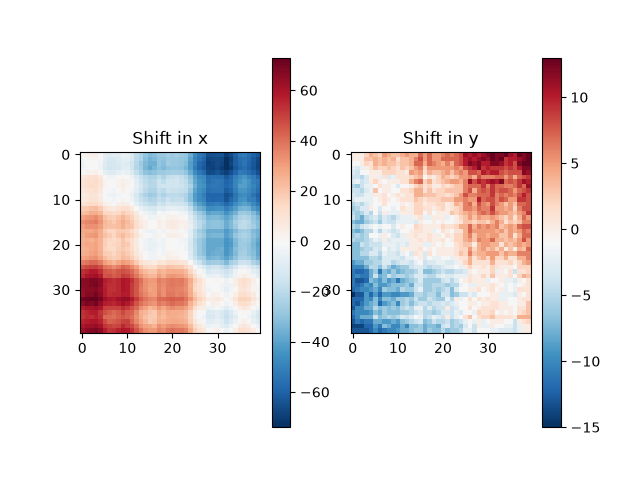

In [90]:
_, axs = plt.subplots(1, 2)
img_sx = axs[0].imshow(measured_shift_matrix[...,0], cmap = "RdBu_r", origin='upper')
axs[0].set_title("Shift in x")
img_sy = axs[1].imshow(measured_shift_matrix[...,1], cmap = "RdBu_r", origin='upper')
axs[1].set_title("Shift in y")
plt.colorbar(img_sx, ax=axs[0])
plt.colorbar(img_sy, ax=axs[1])


In [93]:
fitted, frame_positions, residuals = fit_transitive_shift_matrix(measured_shift_matrix)

Text(0.5, 1.0, 'Shift in X')

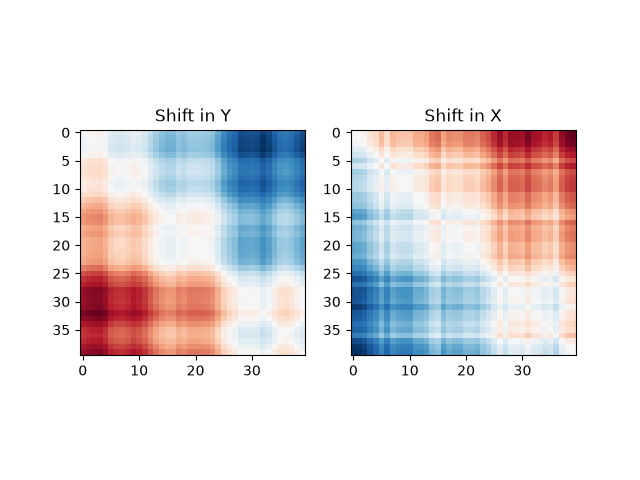

In [94]:
_, axs = plt.subplots(1, 2)
img_sfx = axs[0].imshow(fitted[...,0], cmap = "RdBu_r", origin='upper')
axs[0].set_title("Shift in Y")
img_sfy = axs[1].imshow(fitted[...,1], cmap = "RdBu_r", origin='upper')
axs[1].set_title("Shift in X")

In [95]:
shift_yx = fitted[0, 0:]

In [96]:
from scipy.ndimage import shift

In [35]:
img.shape

(40, 512, 512)

In [97]:
shift_img_stack = np.array([shift(img[i], shift_yx[i], order=1) for i in range(img.shape[0])])

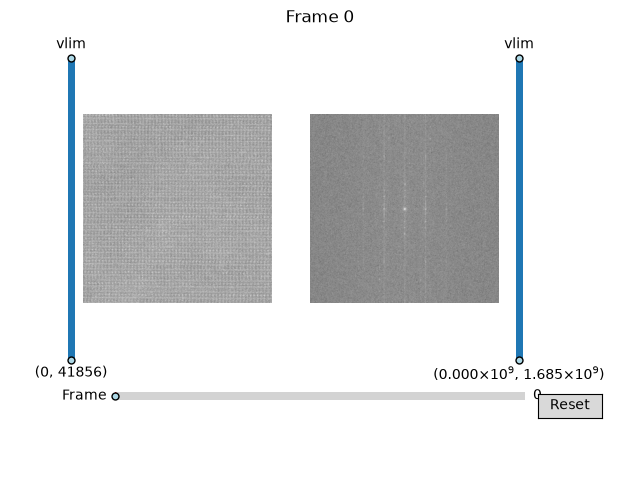

In [98]:
saplt.SliceViewer(shift_img_stack)

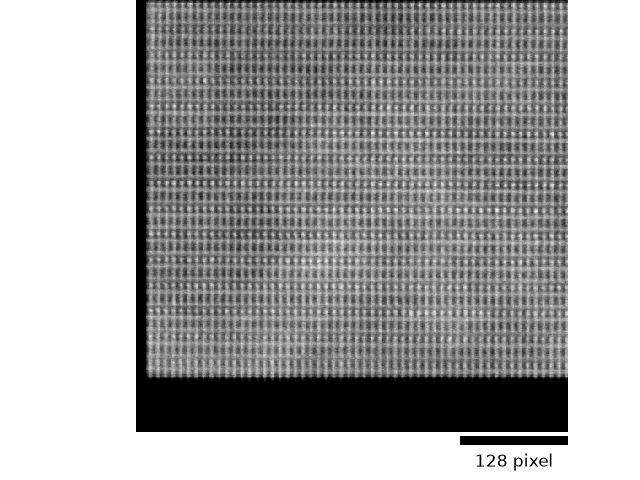

<Axes: >

In [103]:
fig = plt.figure()
saplt.PlotImage(fig, shift_img_stack.mean(0), dr = 1, unit = "pixel", vmin = 2.34e4)

In [122]:
np.save(os.path.join(work_dir, "SI_shift.npy"), shift_yx)

In [123]:
imwrite(os.path.join(work_dir, "shift_img_stack.tif"), shift_img_stack)

# Stitching